# S1.1: frozen multipattern synthetic benchmark

Notebook **не запускает и не настраивает регистрацию**. Он читает batch-артефакты
`sliding-phantom-v3.0-multipattern`, проверяет checksums и визуализирует заранее
замороженный gate. S1.1 использует raw ConvexAdam normal component и шесть гладких
mask-derived tangential modes; synthetic truth доступна только оценщику.

`deep_longitudinal` был добавлен и зафиксирован до реализации/первого batch S1.1.
Даже PASS здесь разрешает только development real pairs, но не карты человека.

**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


RESULTS = ARTIFACT_ROOT / "results/sliding_s1_v1_phantom_v30"
manifest_path = RESULTS / "manifest.json"
summary_path = RESULTS / "summary.csv"
if not manifest_path.is_file() or not summary_path.is_file():
    raise RuntimeError(
        "Нет frozen S1.1 batch-артефактов. Выполните: "
        "breathgeom registration sliding-synthetic"
    )

## Provenance и целостность

Manifest фиксирует commit вычислительного кода, frozen config/suite и SHA-256 всех
диагностических полей. Абсолютные локальные пути в notebook не сохраняются.

In [3]:
def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()


manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
assert sha256(summary_path) == manifest["summary_sha256"]
for filename, expected in manifest["field_sha256"].items():
    assert sha256(RESULTS / filename) == expected

display(
    pd.DataFrame(
        [
            {"Параметр": "suite_version", "Значение": manifest["suite_version"]},
            {"Параметр": "s1_version", "Значение": manifest["s1_version"]},
            {"Параметр": "code_version", "Значение": manifest["code_version"]},
            {"Параметр": "suite_sha256", "Значение": manifest["suite_config"]["sha256"]},
            {"Параметр": "s1_config_sha256", "Значение": manifest["s1_config"]["sha256"]},
            {"Параметр": "artifact_usage", "Значение": manifest["usage"]},
            {"Параметр": "checksum_verdict", "Значение": "PASS"},
        ]
    )
)

,Параметр,Значение
0,suite_version,sliding-phantom-v3.0-multipattern
1,s1_version,s1.1
2,code_version,8a400e46b9c54428fc8c1be7afd1fd7494294412
3,suite_sha256,DA7E5E1713A78944E1533EE1BA187520BB41AF881C5B3E...
4,s1_config_sha256,1B1DED32AEDB38F02A279B78ECF4FABCE91B20F55C2904...
5,artifact_usage,synthetic_diagnostic_ONLY
6,checksum_verdict,PASS


## Case-level gate и modal fit

Единица решения — целый synthetic case. Коэффициенты и objective относятся к fit по
изображениям; endpoint/slip/Jacobian вычисляются оценщиком после возврата поля.

In [4]:
summary = pd.read_csv(summary_path)
summary["gate_reasons"] = summary["gate_reasons"].fillna("")
columns = [
    "case_id",
    "spacing_mm",
    "tangential_slip_truth_mm",
    "endpoint_p95_limit_mm",
    "lung_field_p95_mm",
    "body_field_p95_mm",
    "normal_mismatch_p95_mm",
    "tangential_slip_median_mm",
    "lung_jacobian_p01",
    "body_jacobian_p01",
    "tangential_objective_initial",
    "tangential_objective_final",
    "tangential_optimizer_success",
    "gate_pass",
    "gate_reasons",
]
display(summary[columns].round(3))

gate_matrix = pd.DataFrame(
    {
        "lung field": summary["lung_field_p95_mm"] <= summary["endpoint_p95_limit_mm"],
        "body field": summary["body_field_p95_mm"] <= summary["endpoint_p95_limit_mm"],
        "normal contact": summary["normal_mismatch_p95_mm"]
        <= manifest["gate"]["normal_mismatch_p95_max_mm"],
        "tangential slip": summary["tangential_slip_error_mm"]
        <= manifest["gate"]["tangential_slip_error_max_mm"],
        "lung topology": (
            (summary["lung_jacobian_p01"] >= manifest["gate"]["jacobian_p01_min"])
            & (summary["lung_nonpositive_jacobian_fraction"] == 0)
        ),
        "body topology": (
            (summary["body_jacobian_p01"] >= manifest["gate"]["jacobian_p01_min"])
            & (summary["body_nonpositive_jacobian_fraction"] == 0)
        ),
    }
)
gate_matrix.index = summary["case_id"]
display(gate_matrix)

mode_names = summary.loc[0, "tangential_mode_names"].split(";")
coefficient_table = pd.DataFrame(
    [
        [float(value) for value in row.split(";")]
        for row in summary["tangential_coefficients_mm"]
    ],
    index=summary["case_id"],
    columns=mode_names,
)
display(coefficient_table.round(3))

,case_id,spacing_mm,tangential_slip_truth_mm,endpoint_p95_limit_mm,lung_field_p95_mm,body_field_p95_mm,normal_mismatch_p95_mm,tangential_slip_median_mm,lung_jacobian_p01,body_jacobian_p01,tangential_objective_initial,tangential_objective_final,tangential_optimizer_success,gate_pass,gate_reasons
0,nominal_1mm,1.0x1.0x1.0,4.000,1.50,0.687,0.810,0.074,4.117,1.044,0.851,0.978,0.822,True,True,
1,shallow_1mm,1.0x1.0x1.0,2.000,1.50,0.773,0.745,0.036,1.975,0.819,0.912,0.787,0.698,True,True,
2,deep_anisotropic,1.25x1.25x1.5,6.000,2.25,1.247,1.165,0.276,5.951,1.419,0.869,0.994,0.800,True,True,
3,deep_longitudinal,1.25x1.25x1.5,5.537,2.25,1.359,1.086,0.226,5.055,0.940,0.880,0.996,0.797,True,True,


,lung field,body field,normal contact,tangential slip,lung topology,body topology
case_id,,,,,,
nominal_1mm,True,True,True,True,True,True
shallow_1mm,True,True,True,True,True,True
deep_anisotropic,True,True,True,True,True,True
deep_longitudinal,True,True,True,True,True,True


,rotation_x,rotation_y,rotation_z,projected_x,projected_y,projected_z
case_id,,,,,,
nominal_1mm,-0.014,0.021,4.075,0.023,-0.116,0.007
shallow_1mm,0.057,-0.001,1.972,-0.032,0.001,-0.015
deep_anisotropic,0.215,0.124,6.100,-0.368,-0.277,0.045
deep_longitudinal,0.028,0.220,0.088,-0.186,0.056,5.520


## Ошибки, slip и выбранные моды

Отдельно показано, насколько modal fit снизил собственную image-objective. Снижение
objective не заменяет независимые endpoint/slip/topology gates.

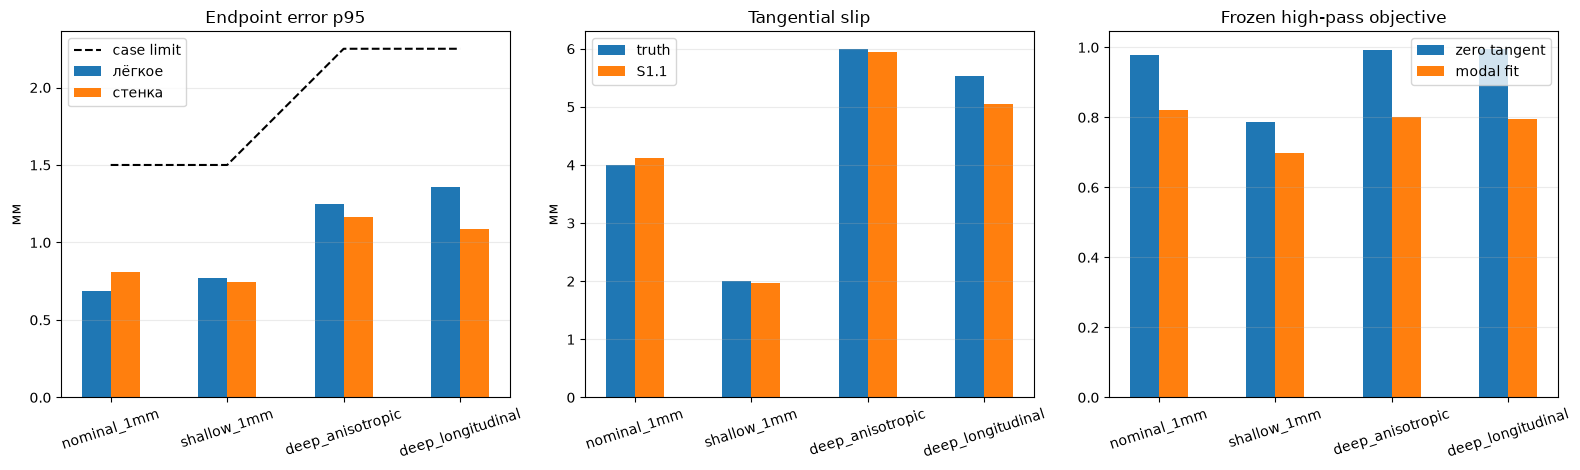

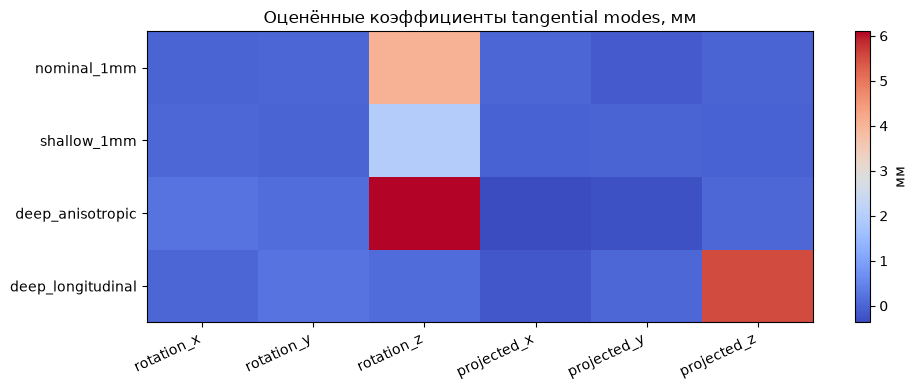

In [5]:
labels = summary["case_id"].tolist()
x = np.arange(len(summary))
width = 0.25
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].bar(x - width / 2, summary["lung_field_p95_mm"], width, label="лёгкое")
axes[0].bar(x + width / 2, summary["body_field_p95_mm"], width, label="стенка")
axes[0].plot(x, summary["endpoint_p95_limit_mm"], "k--", label="case limit")
axes[0].set_title("Endpoint error p95")
axes[0].set_ylabel("мм")
axes[0].legend()

axes[1].bar(x - width / 2, summary["tangential_slip_truth_mm"], width, label="truth")
axes[1].bar(x + width / 2, summary["tangential_slip_median_mm"], width, label="S1.1")
axes[1].set_title("Tangential slip")
axes[1].set_ylabel("мм")
axes[1].legend()

axes[2].bar(x - width / 2, summary["tangential_objective_initial"], width, label="zero tangent")
axes[2].bar(x + width / 2, summary["tangential_objective_final"], width, label="modal fit")
axes[2].set_title("Frozen high-pass objective")
axes[2].legend()

for ax in axes:
    ax.set_xticks(x, labels, rotation=18)
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
image = ax.imshow(coefficient_table.to_numpy(), cmap="coolwarm", aspect="auto")
ax.set_xticks(np.arange(len(mode_names)), mode_names, rotation=25, ha="right")
ax.set_yticks(np.arange(len(coefficient_table)), coefficient_table.index)
ax.set_title("Оценённые коэффициенты tangential modes, мм")
fig.colorbar(image, ax=ax, label="мм")
plt.tight_layout()
plt.show()

## Независимая spatial диагностика

Для каждого case сравнивается исходный ConvexAdam lung field и итог S1.1. Карты и
z-регионы — диагностика внутри case, а не независимые статистические наблюдения.

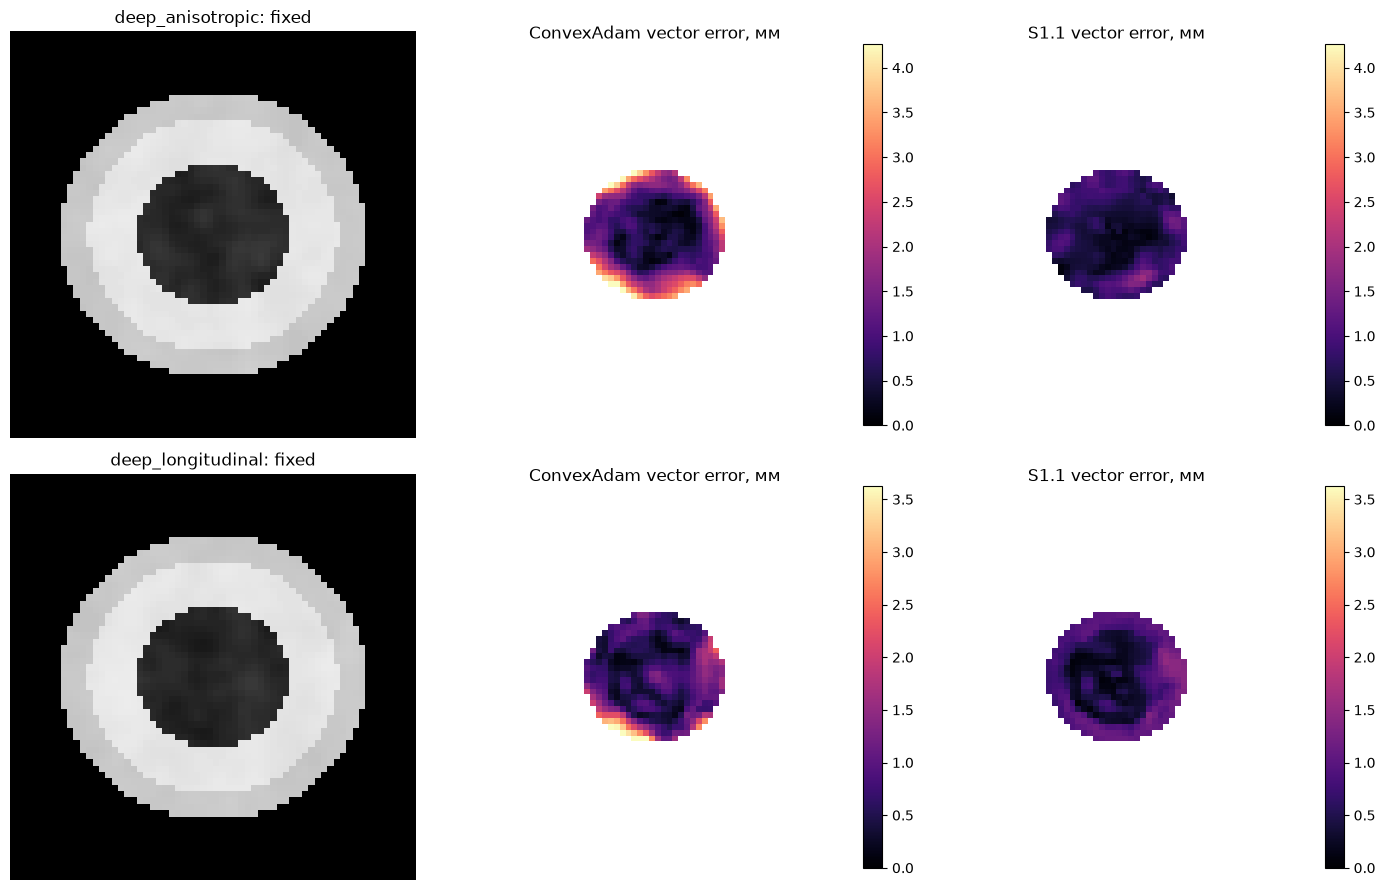

,case_id,"ConvexAdam p95, мм","S1.1 p95, мм"
0,nominal_1mm,1.430,0.687
1,shallow_1mm,1.088,0.773
2,deep_anisotropic,3.686,1.247
3,deep_longitudinal,2.247,1.359


,case_id,z_region,voxel_count,mean_mm,p95_mm,maximum_mm
0,nominal_1mm,inferior,6356,0.489,0.755,1.036
1,nominal_1mm,middle,11636,0.369,0.649,1.018
2,nominal_1mm,superior,5640,0.459,0.658,0.863
3,shallow_1mm,inferior,6356,0.412,0.782,1.051
4,shallow_1mm,middle,11636,0.340,0.792,0.975
5,shallow_1mm,superior,5640,0.328,0.626,0.763
6,deep_anisotropic,inferior,2116,0.810,1.192,1.829
7,deep_anisotropic,middle,3672,0.712,1.165,1.901
8,deep_anisotropic,superior,1740,0.908,1.382,2.076
9,deep_longitudinal,inferior,2116,1.098,1.586,2.072


In [6]:
field_rows = []
localisation_rows = []
selected_cases = ["deep_anisotropic", "deep_longitudinal"]
fig, axes = plt.subplots(len(selected_cases), 3, figsize=(14, 9))
for case_id in summary["case_id"]:
    with np.load(RESULTS / f"{case_id}.npz") as artifact:
        fixed = artifact["fixed_image"]
        lung_mask = artifact["fixed_lung_mask"].astype(bool)
        truth = artifact["truth_lung_displacement_mm"]
        initial = artifact["initial_lung_displacement_mm"]
        estimated = artifact["estimated_lung_displacement_mm"]
        initial_error = np.linalg.norm(initial - truth, axis=-1)
        final_error = np.linalg.norm(estimated - truth, axis=-1)
    field_rows.append(
        {
            "case_id": case_id,
            "ConvexAdam p95, мм": float(np.percentile(initial_error[lung_mask], 95)),
            "S1.1 p95, мм": float(np.percentile(final_error[lung_mask], 95)),
        }
    )
    active_z = np.flatnonzero(np.any(lung_mask, axis=(0, 1)))
    for region, z_indices in zip(
        ["inferior", "middle", "superior"],
        np.array_split(active_z, 3),
        strict=True,
    ):
        z_band = np.zeros(lung_mask.shape[2], dtype=bool)
        z_band[z_indices] = True
        values = final_error[lung_mask & z_band[None, None, :]]
        localisation_rows.append(
            {
                "case_id": case_id,
                "z_region": region,
                "voxel_count": len(values),
                "mean_mm": float(np.mean(values)),
                "p95_mm": float(np.percentile(values, 95)),
                "maximum_mm": float(np.max(values)),
            }
        )
    if case_id in selected_cases:
        plot_row = selected_cases.index(case_id)
        z_index = fixed.shape[2] // 2
        axes[plot_row, 0].imshow(
            fixed[:, :, z_index].T,
            cmap="gray",
            origin="lower",
            vmin=-1000,
            vmax=150,
        )
        axes[plot_row, 0].set_title(f"{case_id}: fixed")
        initial_slice = np.where(lung_mask[:, :, z_index], initial_error[:, :, z_index], np.nan).T
        final_slice = np.where(lung_mask[:, :, z_index], final_error[:, :, z_index], np.nan).T
        vmax = float(np.nanpercentile(initial_slice, 99))
        first = axes[plot_row, 1].imshow(
            initial_slice,
            cmap="magma",
            origin="lower",
            vmin=0,
            vmax=vmax,
        )
        axes[plot_row, 1].set_title("ConvexAdam vector error, мм")
        fig.colorbar(first, ax=axes[plot_row, 1], fraction=0.046)
        second = axes[plot_row, 2].imshow(
            final_slice,
            cmap="magma",
            origin="lower",
            vmin=0,
            vmax=vmax,
        )
        axes[plot_row, 2].set_title("S1.1 vector error, мм")
        fig.colorbar(second, ax=axes[plot_row, 2], fraction=0.046)
        for ax in axes[plot_row]:
            ax.set_axis_off()
plt.tight_layout()
plt.show()
display(pd.DataFrame(field_rows).round(3))
display(pd.DataFrame(localisation_rows).round(3))

In [7]:
pass_count = int(summary["gate_pass"].sum())
case_count = len(summary)
unseen = summary.loc[summary["case_id"] == "deep_longitudinal"].iloc[0]
if manifest["all_pass"]:
    verdict = (
        f"## Итог: S1.1 synthetic gate PASS ({pass_count}/{case_count})\n\n"
        f"Новый deep_longitudinal: lung p95 {unseen.lung_field_p95_mm:.3f} мм при "
        f"лимите {unseen.endpoint_p95_limit_mm:.3f} мм; slip "
        f"{unseen.tangential_slip_median_mm:.3f} мм при truth "
        f"{unseen.tangential_slip_truth_mm:.3f} мм. Folding нет.\n\n"
        "**Разрешён следующий шаг: S1.1 на development real pairs без expert "
        "landmarks.** Карты формы/толщины всё ещё запрещены до реальных Gate 1L/1B. "
        "Synthetic PASS не доказывает достаточность шести мод для настоящего лёгкого."
    )
else:
    failures = summary.loc[~summary["gate_pass"], ["case_id", "gate_reasons"]]
    failure_text = "; ".join(
        f"{row.case_id}: {row.gate_reasons}" for row in failures.itertuples()
    )
    verdict = (
        f"## Итог: S1.1 synthetic gate FAIL ({pass_count}/{case_count})\n\n"
        f"Провалы: {failure_text}. Real-pair benchmark и карты заблокированы."
    )
display(Markdown(verdict))

## Итог: S1.1 synthetic gate PASS (4/4)

Новый deep_longitudinal: lung p95 1.359 мм при лимите 2.250 мм; slip 5.055 мм при truth 5.537 мм. Folding нет.

**Разрешён следующий шаг: S1.1 на development real pairs без expert landmarks.** Карты формы/толщины всё ещё запрещены до реальных Gate 1L/1B. Synthetic PASS не доказывает достаточность шести мод для настоящего лёгкого.